Relatório Técnico: Análise Topológica e Modelagem Estatística do Dataset Amazon 0302

###**1. Caracterização Geral do Dataset**

Objeto de Estudo: Dataset Amazon 0302 (Origem: SNAP). Esta rede representa relações de co-compra entre produtos, onde os vértices correspondem a itens do catálogo e as arestas direcionadas indicam que o produto v é frequentemente adquirido em conjunto com o produto w. A topologia reflete a estrutura de recomendação da plataforma em março de 2003.

As métricas fundamentais extraídas do processamento técnico são apresentadas na tabela abaixo:

|| Valores
| :--- | ---: |
| Número de Vértices | 262.111
| Número de Arestas | 1.234.877
| Grau Médio de Saída | 4,71
| Densidade da Rede | 1,797 × $10^5$
| Grau Máximo de Entrada (In-degree) | 420
| Grau Máximo de Saída (Out-degree) | 5

###**2. Metodologia de Processamento e Análise**

O pipeline de dados foi estruturado em duas etapas principais, priorizando a escalabilidade e o rigor estatístico:

* Construção e Extração (Java):
  * Utilização da biblioteca `Algs4 (Princeton)` para implementação da classe `Digraph`. Esta abordagem foi selecionada pela eficiência de memória no manejo de 1,2 × $10^6$ arestas.
  * Processamento do arquivo .txt original e extração sistemática das frequências de graus.
  * Exportação de dados tratados para arquivos .csv `(distribuicao_indegree.csv e distribuicao_outdegree.csv)`.
* Análise Estatística e Visualização (Python):
  * `Pandas`: Manipulação de dados tabulares e ordenação de frequências.
  * `Matplotlib`: Geração de visualizações em escala log-log para identificação de fenômenos de cauda longa.
  * `Powerlaw`: Implementação de estimativas de máxima verossimilhança para ajuste de modelos e realização de testes de hipótese comparativos.

###**3. Análise da Distribuição de Graus de Entrada (In-degree)**

A distribuição de graus de entrada exibe uma morfologia de "cauda longa" (long tail), típica de redes complexas autorganizáveis. Observa-se que a maioria dos vértices possui conectividade mínima, enquanto uma pequena fração de nós atua como hubs, acumulando até 420 conexões de entrada.

Existe um contraste estrutural crítico entre as distribuições de entrada e saída: enquanto o In-degree é governado por processos de conexão preferencial, o Out-degree é estritamente limitado a um máximo de k=5. Esta limitação não é uma propriedade natural de escala, mas um artefato estrutural do algoritmo de recomendação da Amazon à época, que restringia o número de sugestões visíveis por produto.

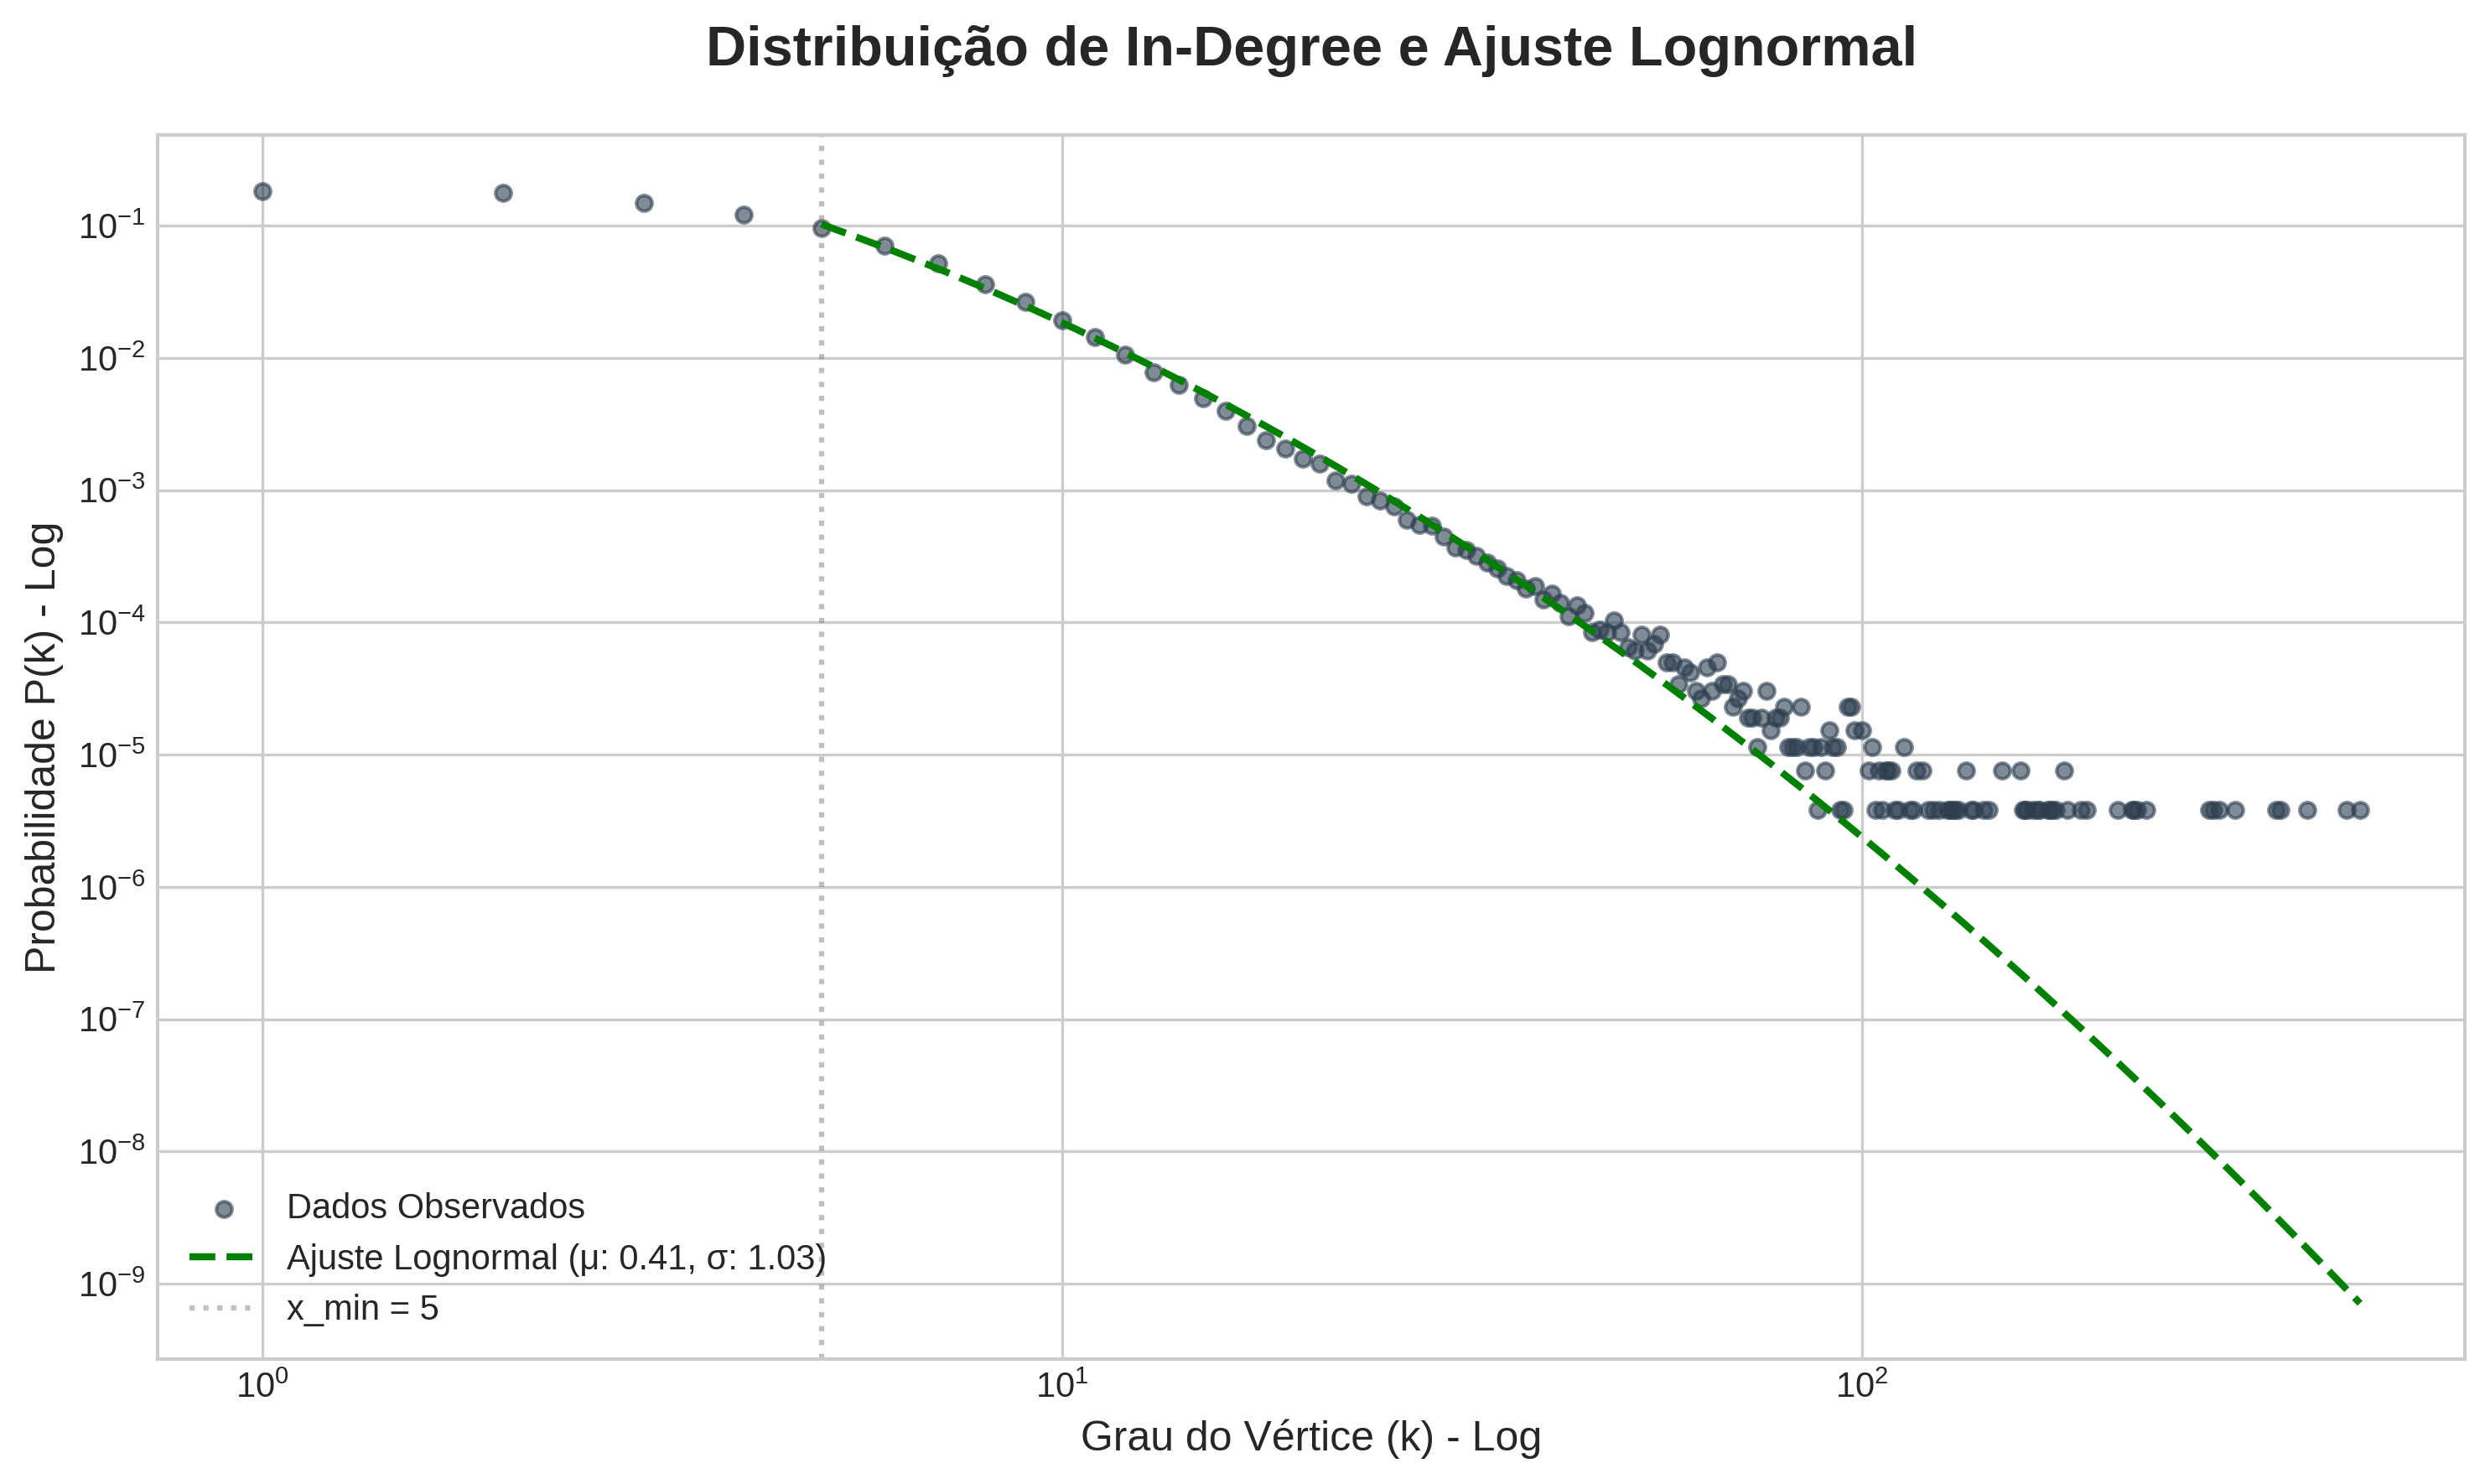

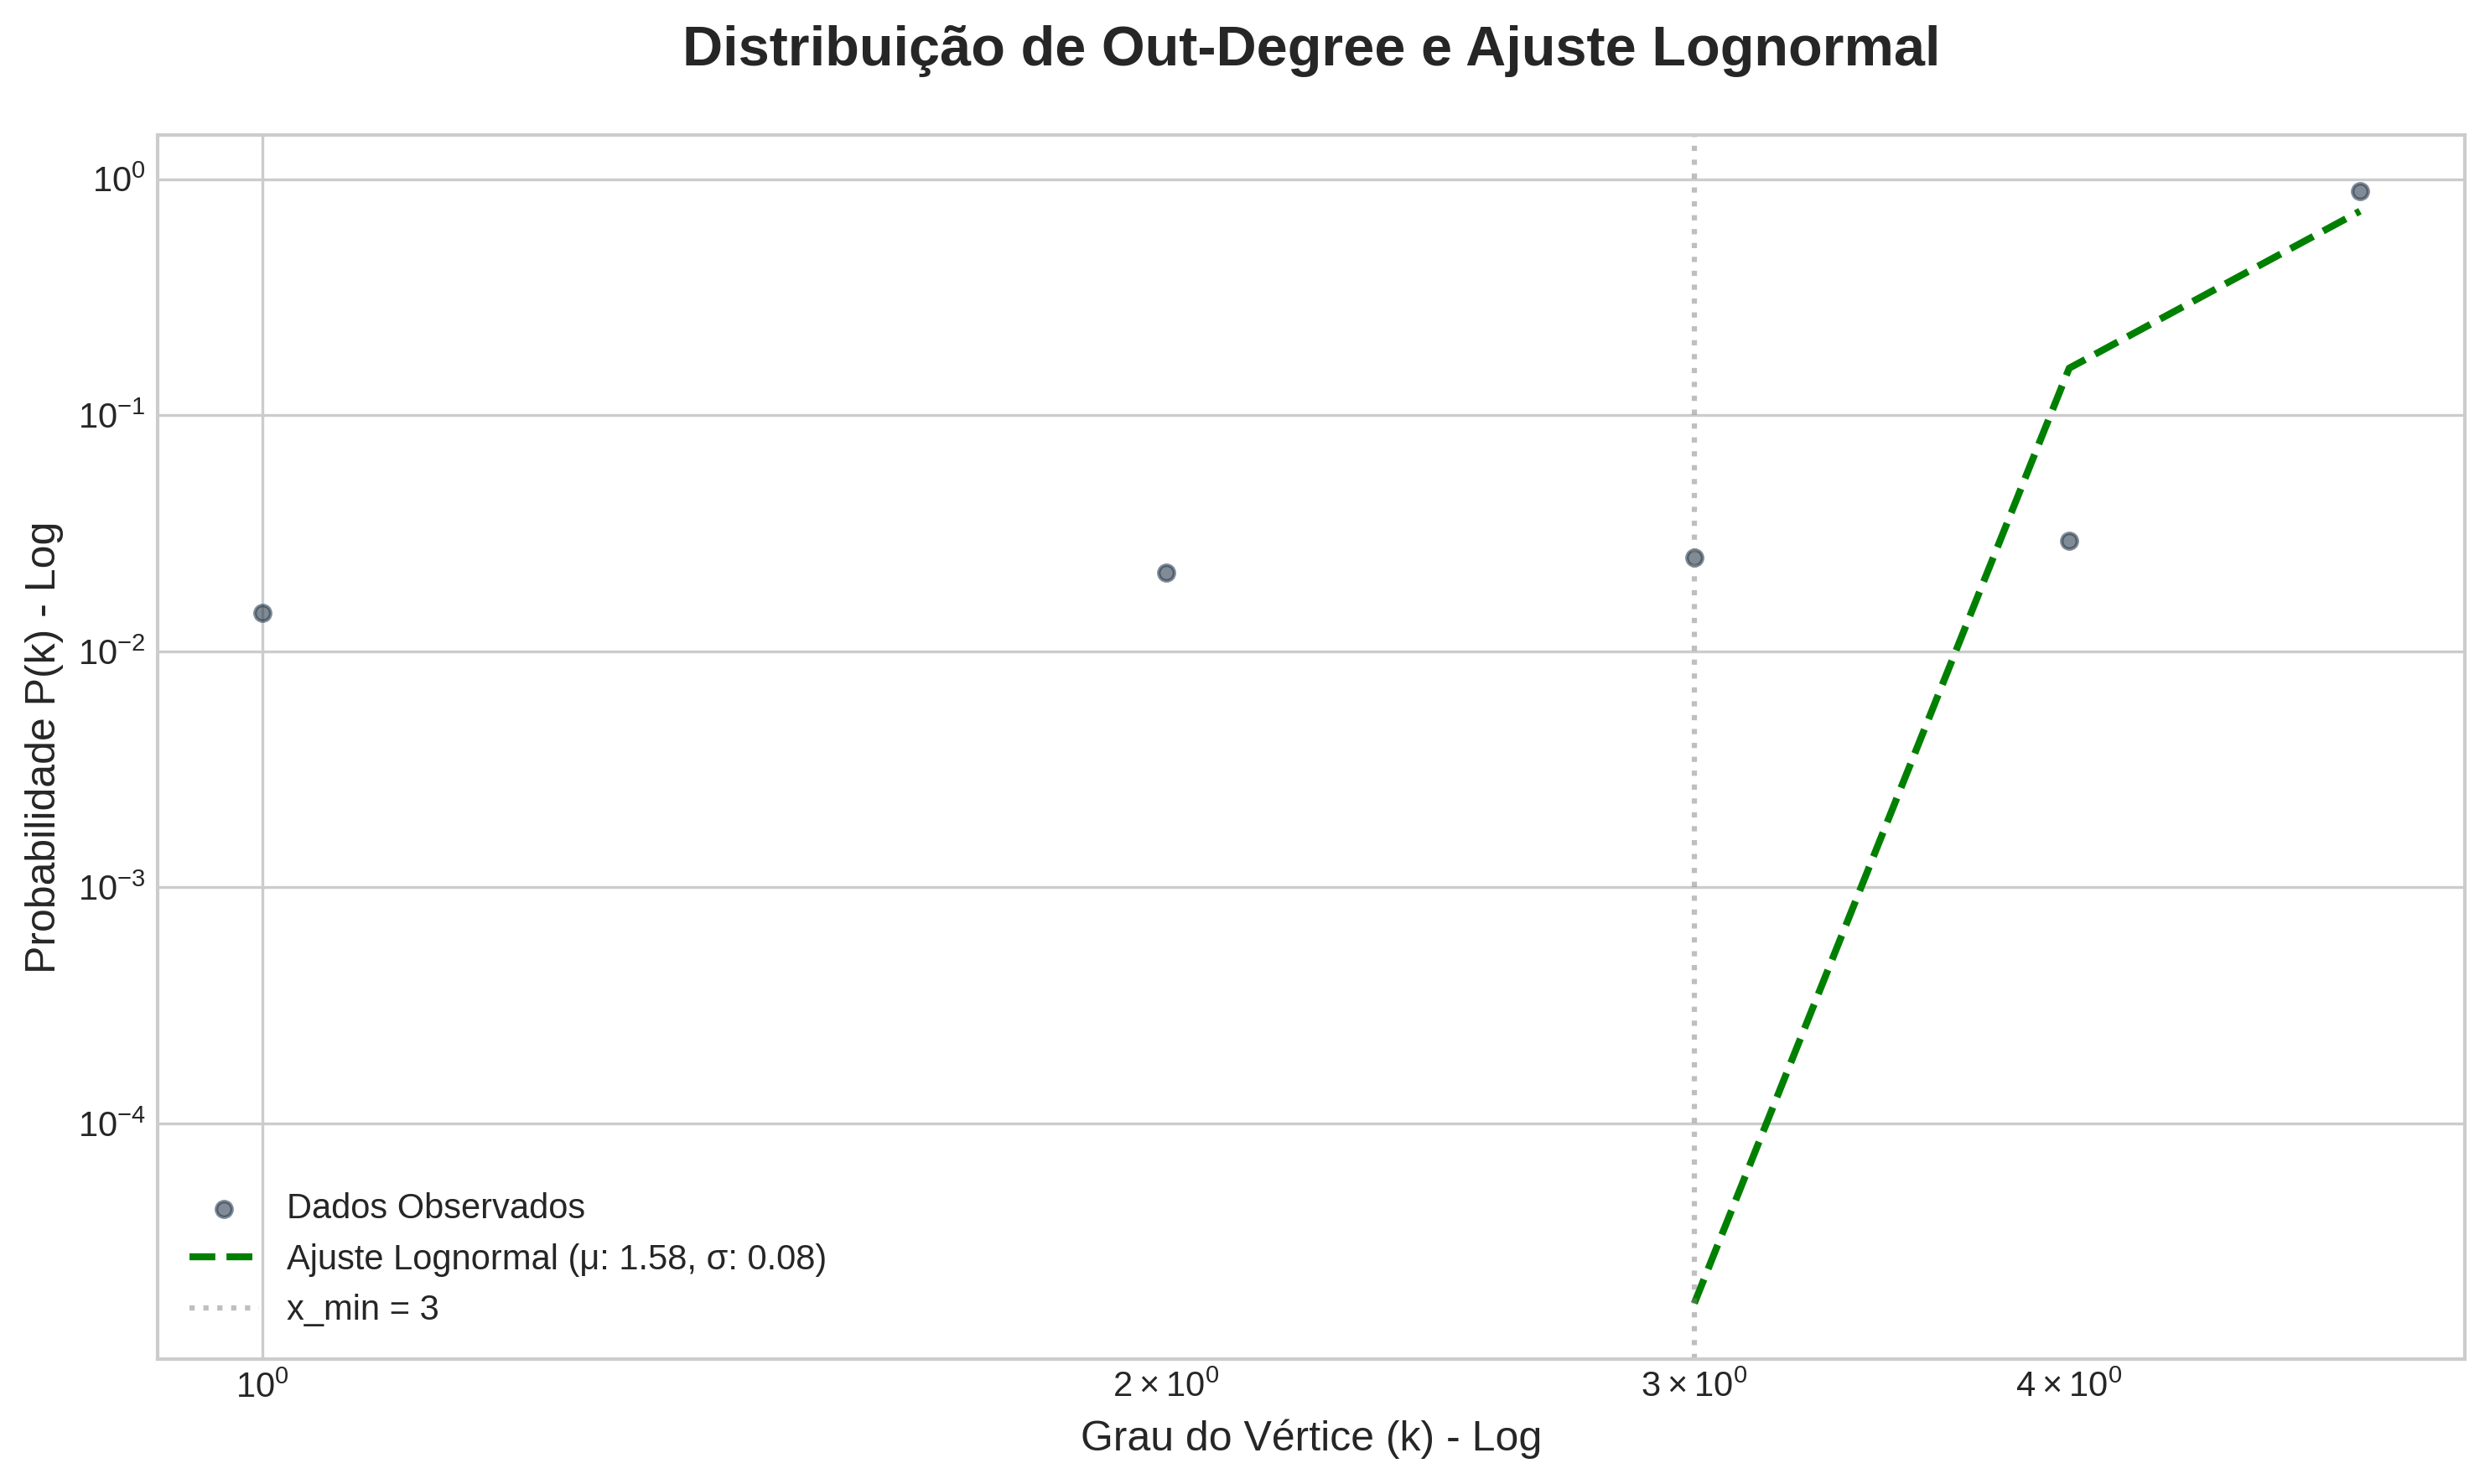

###**4. Comparação Estatística de Modelos de Ajuste**

Para a modelagem do In-degree, aplicou-se uma comparação rigorosa entre os modelos de Lei de Potência (Power Law) e Lognormal para o regime de cauda onde k $\geq$ x_min.

Parâmetros de Ajuste Obtidos:

* Expoente Power Law (α): 2,92.
* Parâmetros Lognormal: μ = 0,41 e σ = 1,03.
* Ponto de corte (x_min): 5.

```
Comparação (R): -1306.0739860637632
P-value: 4.247360359268498e-124
Lognormal MU = 0.41424216569352024
Lognormal SIGMA = 1.026335877697289
X_MIN = 5.0
KS = 0.02645662842743246
```

Justificativa Estatística da Preferência pelo Modelo Lognormal

A análise demonstra que, embora a rede apresente características de escala, o modelo Lognormal é estatisticamente superior para descrever o In-degree deste dataset:

* `Log-likelihood Ratio (R): -1306,07`. O sinal negativo indica de forma inequívoca que o modelo Lognormal possui maior verossimilhança em comparação à Lei de Potência.
* P-value: 4,24 × $10^{-124}$. Este valor evidencia uma significância estatística extrema, descartando a hipótese de que a superioridade do ajuste lognormal seja aleatória.
* `Estatística Kolmogorov-Smirnov (KS): 0,026`. Este valor representa a distância máxima (D) entre a Função de Distribuição Acumulada (CDF) empírica e a teórica. O baixo valor de D ratifica a forte aderência do modelo lognormal aos dados observados.

O modelo de Lei de Potência falha em capturar com precisão a "cabeça" e o "ombro" da distribuição logo após o ponto de corte x_{min} = 5, enquanto a curva Lognormal acomoda melhor a curvatura inicial dos dados antes de convergir para a cauda.

###**5. O Ajuste Power Law**

Como já evidenciado pelos dados estatísticos o modelo Power Law é insuficiente para representar a rede, também ficando mais evidente na forma de como a reta se comporta no gráfico de distribuição abaixo:

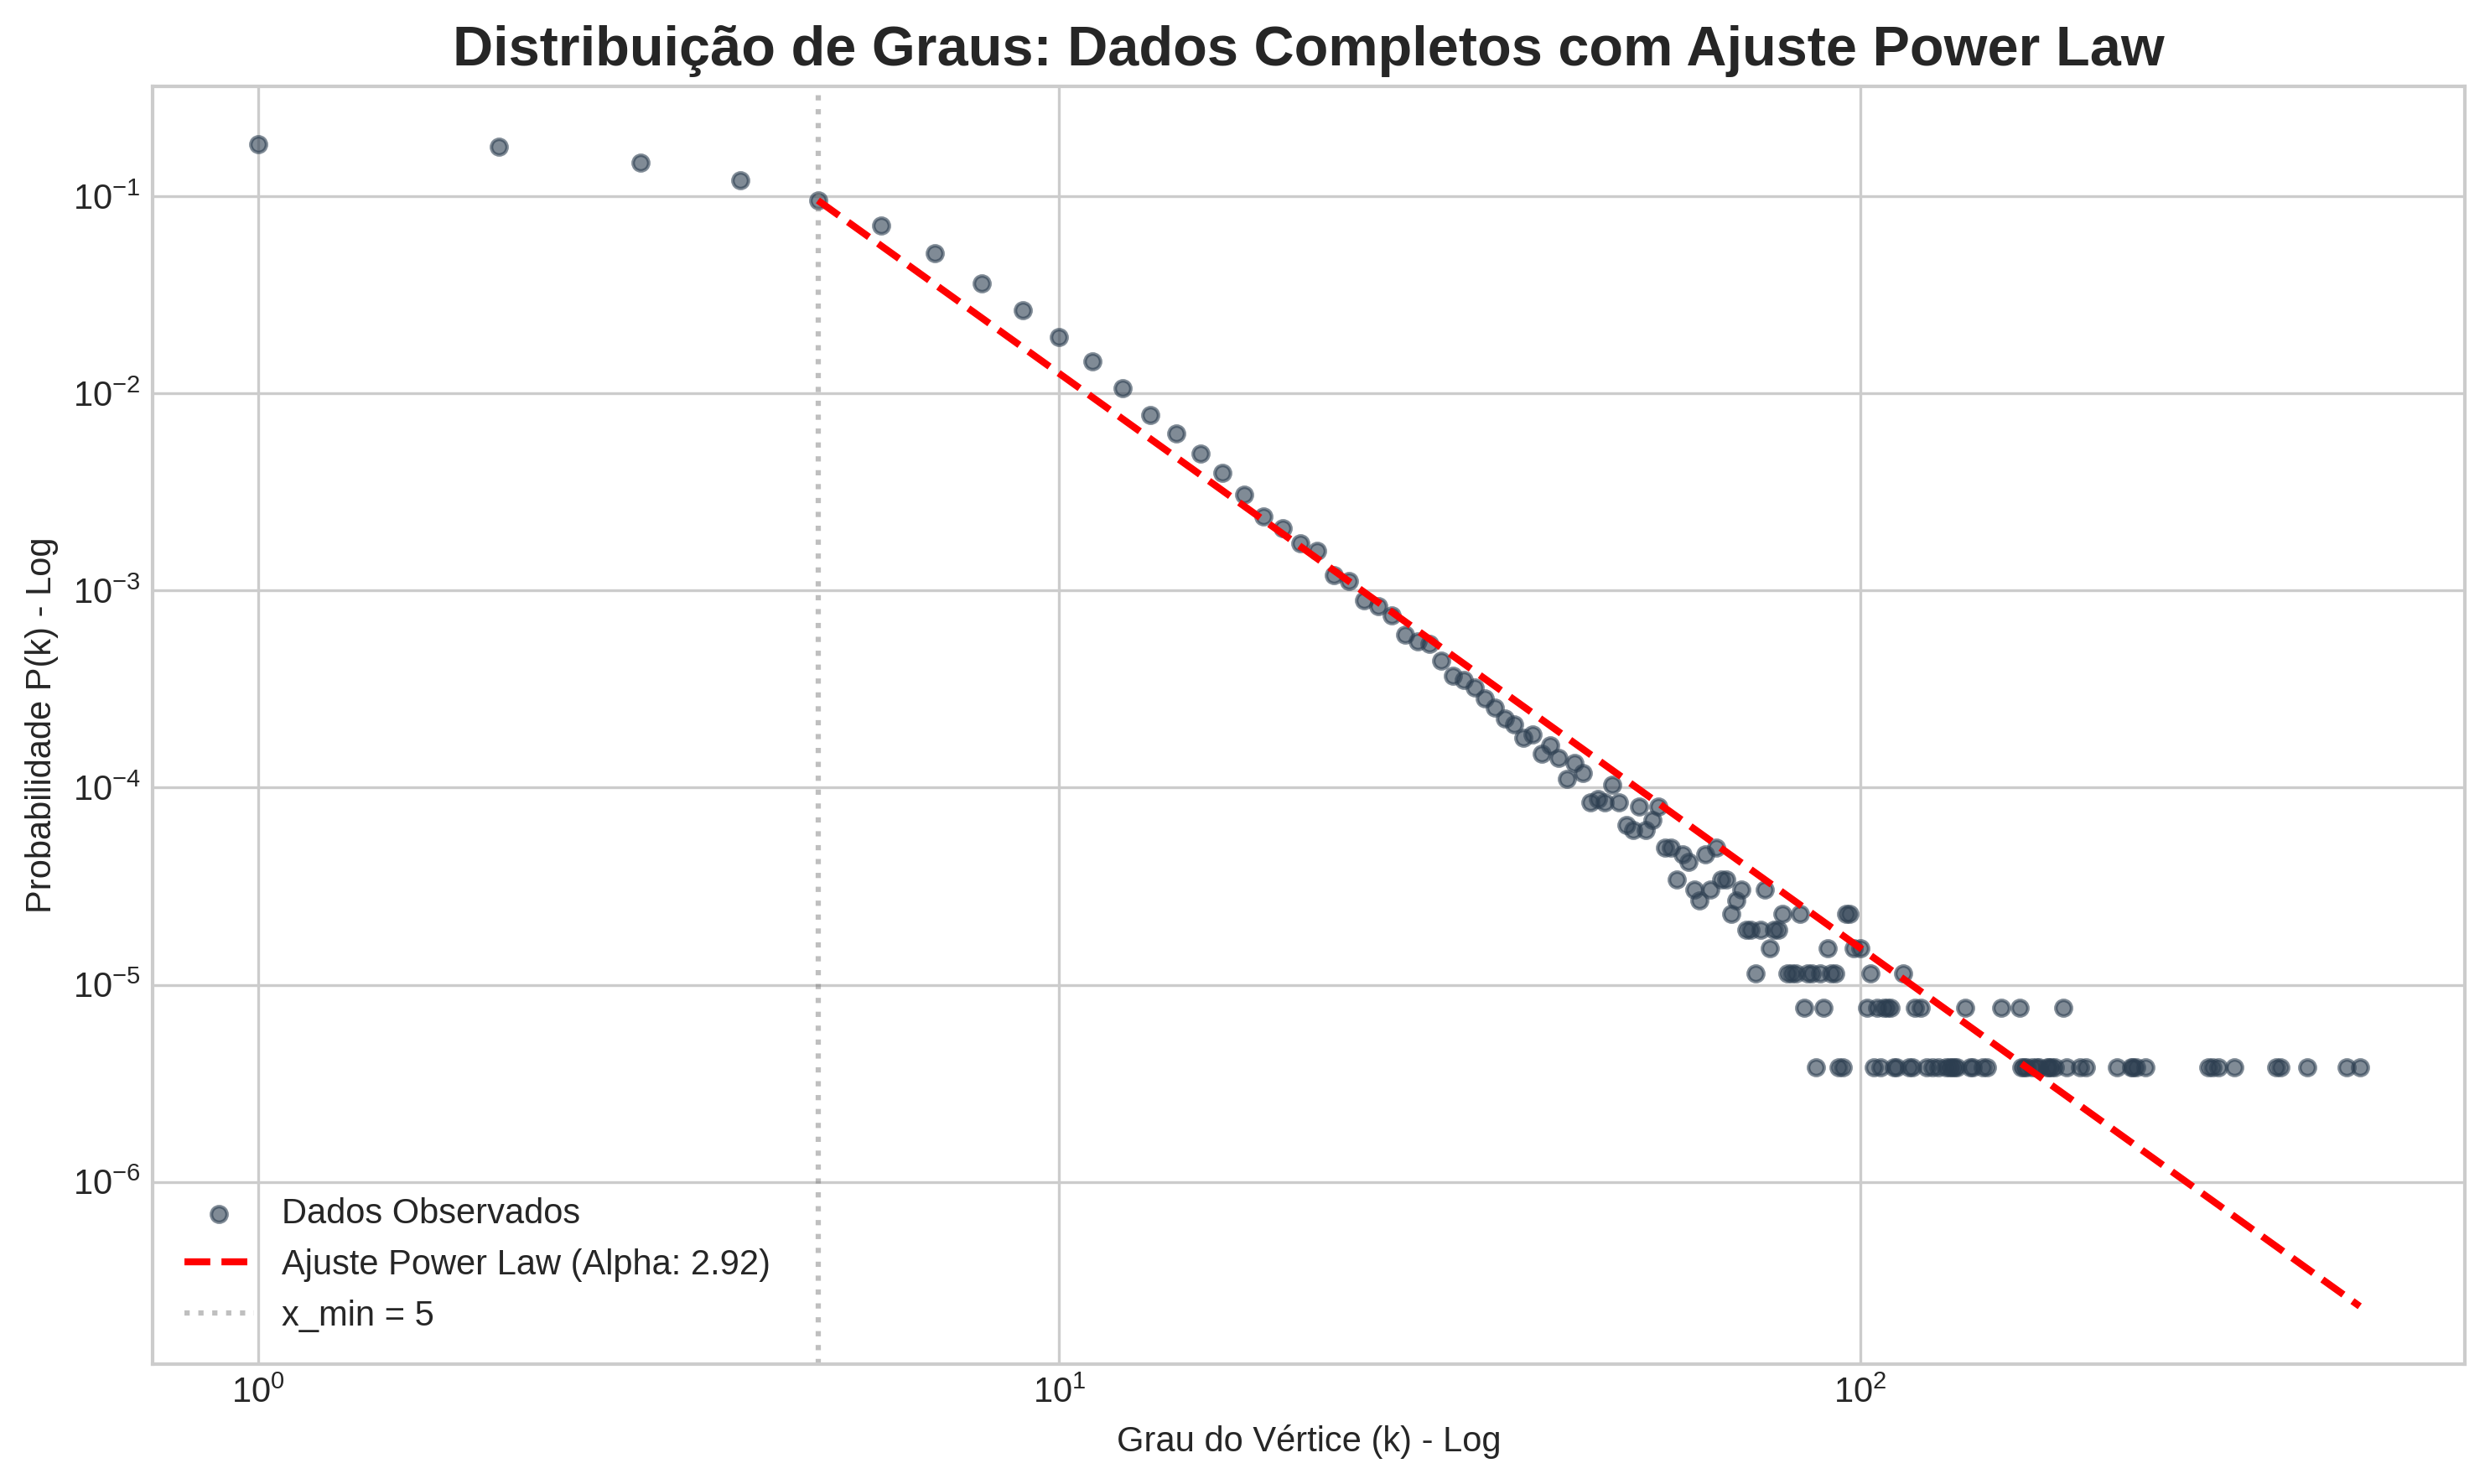

Existem alguns fatores que contribuem para isso, o principal deve ser o comportamento do Dataset ter seu crescimento baseado em processos multiplicativos, ao contrário do fênomeno Preferential Attachment presente em redes scale-free.

###**6. Considerações Visuais e Conclusão**

As evidências visuais em escala log-log confirmam os indicadores numéricos. O ajuste Lognormal descreve com maior precisão a transição de probabilidade para valores baixos de k, onde a Lei de Potência superestima a frequência de nós.

Em síntese, a rede Amazon 0302 é uma estrutura esparsa com uma assimetria fundamental de conectividade. Enquanto a saída é truncada artificialmente em k=5, a entrada de conexões segue uma distribuição lognormal para k \geq 5. Estes resultados reforçam a necessidade de testes de hipótese rigorosos em ciência de redes, demonstrando que aparências de "escala livre" visual podem, sob análise estatística de máxima verossimilhança, revelar distribuições lognormais mais complexas.
